## PROYECTO 3

### Imports

In [1]:
import os
import copy
import torch
from torch.utils.data import DataLoader, Subset
import pytorch_lightning as pl
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import EarlyStopping
from pytorch_lightning.loggers import WandbLogger
from PIL import Image
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from latent_analysis import *
import wandb
from utils.data_module import ButterflyDataModule
from utils.transforms import get_denoising_transform

from utils.visualization import plot_distribution, plot_samples_per_species, display_sample_images
from Unet import UNet
from VAE import VAE
from Unet_Classifier import UNet_Classifier
from latent_analysis import extract_latent_vectors

/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c104warnERKNS_7WarningE'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpe

## Dataset

### Análisis de distribución

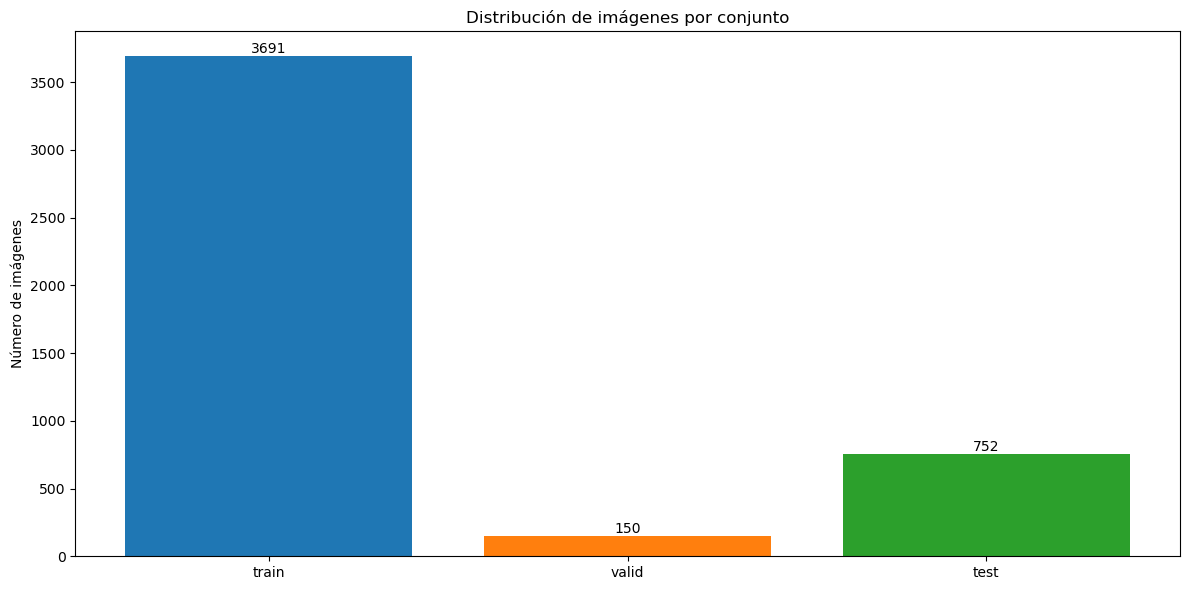

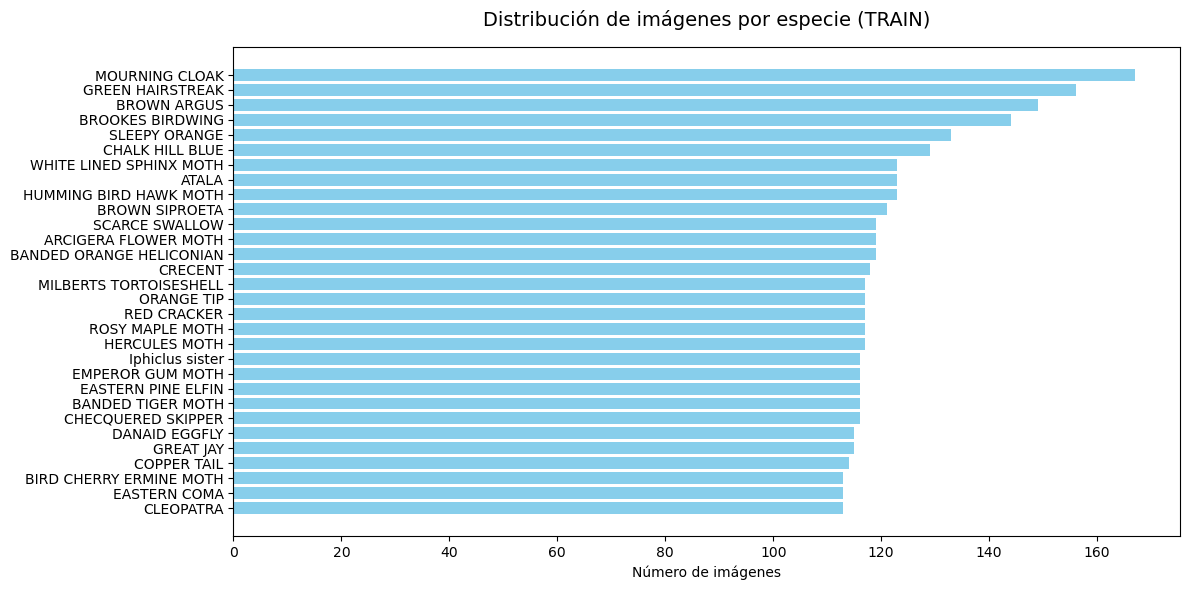

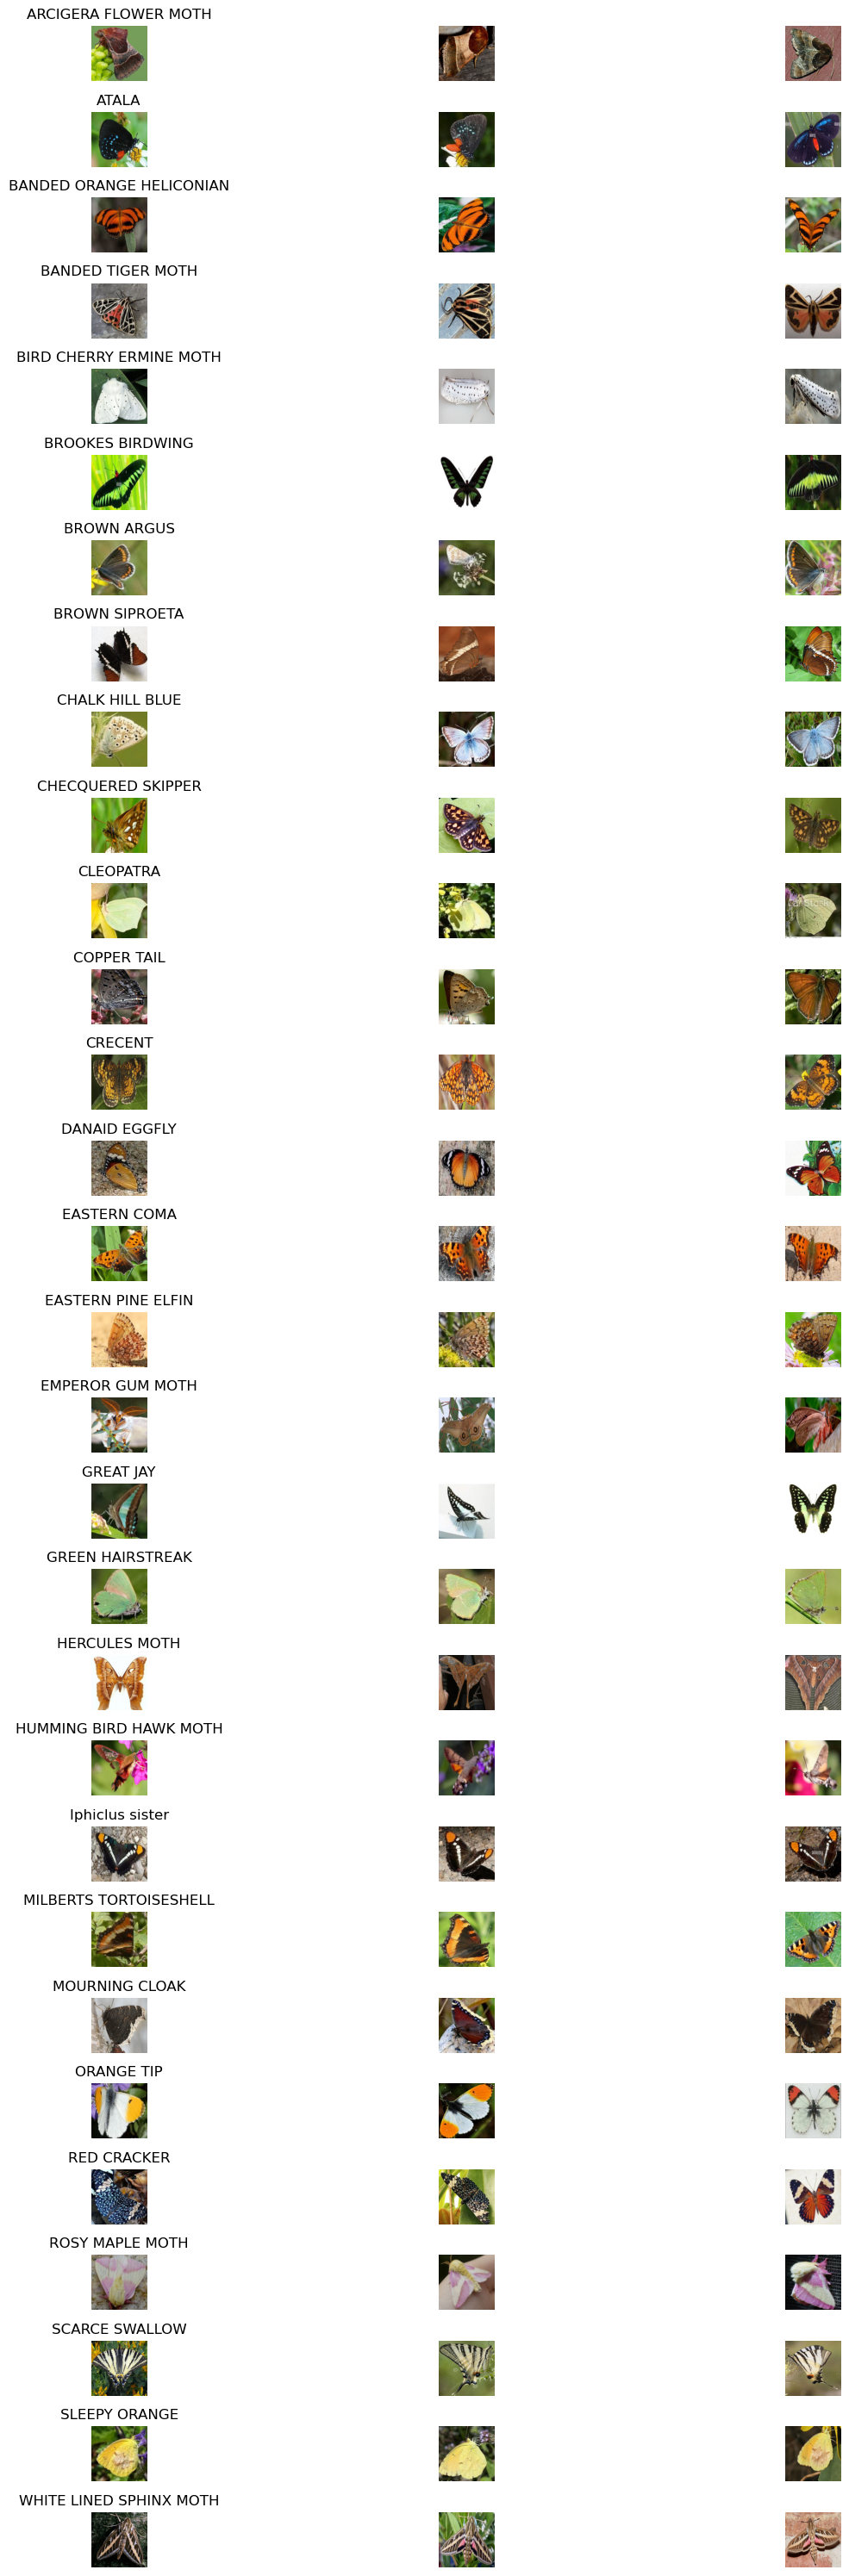

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


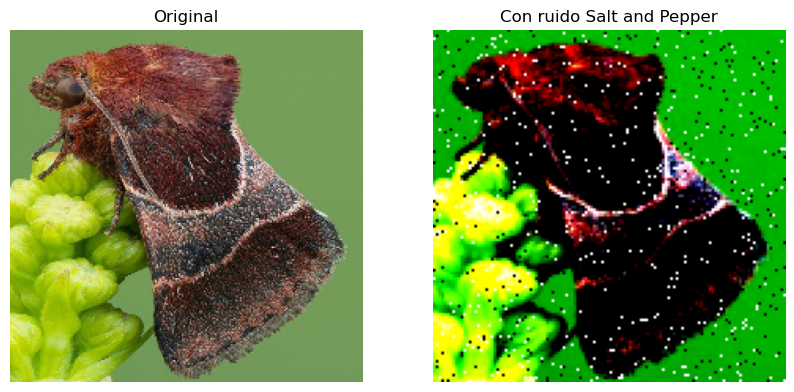

In [2]:
# Análisis de estructura
def analyze_dataset_structure(base_path="dataset"):
    splits = ['train', 'valid', 'test']
    structure = {split: defaultdict(int) for split in splits}
    
    for split in splits:
        split_path = os.path.join(base_path, split)
        for species in os.listdir(split_path):
            species_path = os.path.join(split_path, species)
            if os.path.isdir(species_path):
                num_images = len([f for f in os.listdir(species_path) if f.lower().endswith('.jpg')])
                structure[split][species] = num_images
    return structure

dataset_structure = analyze_dataset_structure()



# Inicialización y verificación
datamodule = ButterflyDataModule(data_root="dataset", batch_size=32)
datamodule.setup()

# Visualizaciones
plot_distribution(dataset_structure)
plot_samples_per_species(dataset_structure, split='train')
display_sample_images(datamodule.train_dataset_labeled, n_samples=3)

# Ejemplo de transformación de denoising
sample_img = Image.open(datamodule.train_dataset_labeled.samples[0][0])
noisy_img = get_denoising_transform()(sample_img)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(sample_img)
plt.title("Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(noisy_img.permute(1, 2, 0))
plt.title("Con ruido Salt and Pepper")
plt.axis('off')
plt.show()

#### Early Stop Callback

In [2]:
# Callback de EarlyStopping (opcional pero recomendado)
early_stop = EarlyStopping(
    monitor="val_loss",  # o "val_loss" si tienes validación
    patience=5,
    verbose=True,
    mode="min"
)


### Crear DataModules de PyTorch

In [5]:
# Usamos tu DataModule
dm73 = ButterflyDataModule(data_root="/data/lnavarro/p3_data", batch_size=32)
dm91 = ButterflyDataModule(data_root="/data/lnavarro/p3_data", batch_size=32, labeled_percentage=0.1)
dm73.setup()
dm91.setup()
wandb_logger = WandbLogger(project="butterfly_unet")

## Hipotesis 1

### Grid Search

##### UNet Base

In [9]:
wandb_logger = WandbLogger(project="butterfly_unet")
wandb_logger.experiment.config["gs"] = True
wandb_logger.experiment.config["model"] = "UNet"
lr1, lr2, lr3, l4 = [1e-3, 1e-4, 1e-5, 5e-4]
os.environ["SLURM_NTASKS_PER_NODE"] = "4"
gs_trainer = Trainer(
    max_epochs=4,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger,
    callbacks=[early_stop]
)

/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:396: UserWarning: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
  rank_zero_warn(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [12]:
ae1 = UNet(in_channels=3, out_channels=1, lr=lr1)
gs_trainer.fit(
    ae1,
    train_dataloaders=dm73.train_dataloader(),
    val_dataloaders=dm73.val_dataloader()
)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name       | Type            | Params
------------------------------------------------
0  | encoder1   | DoubleConv      | 39.0 K
1  | pool1      | MaxPool2d       | 0     
2  | encoder2   | DoubleConv      | 221 K 
3  | pool2      | MaxPool2d       | 0     
4  | encoder3   | DoubleConv      | 886 K 
5  | pool3      | MaxPool2d       | 0     
6  | bottleneck | DoubleConv      | 3.5 M 
7  | upconv3    | ConvTranspose2d | 524 K 
8  | decoder3   | DoubleConv      | 1.8 M 
9  | upconv2    | ConvTranspose2d | 131 K 
10 | decoder2   | DoubleConv      | 443 K 
11 | upconv1    | ConvTranspose2d | 32.8 K
12 | decoder1   | DoubleConv      | 110 K 
13 | final_conv | Conv2d          | 195   
------------------------------------------------
7.7 M     Trainable params
0         Non-trainable params
7.7 M     Total params
30.812    Total estimated model params size (MB)
SLURM auto-requeueing enabled. Setting signal handlers.


Epoch 0:   0%|          | 0/35 [00:00<?, ?it/s] 

/home/lnavarro/tec/p3/Unet.py:71: UserWarning: Using a target size (torch.Size([32])) that is different to the input size (torch.Size([32, 3, 128, 128])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(x_hat, y)


RuntimeError: The size of tensor a (128) must match the size of tensor b (32) at non-singleton dimension 3

In [ ]:
ae2 = UNet(in_channels=3, out_channels=1, lr2)
gs_trainer.fit(
    ae2,
    train_dataloaders=dm73.train_dataloader(),
    val_dataloaders=dm73.val_dataloader()
)

In [ ]:
ae3 = UNet(in_channels=3, out_channels=1, lr3)
gs_trainer.fit(
    ae3,
    train_dataloaders=dm73.train_dataloader(),
    val_dataloaders=dm73.val_dataloader()
)

In [ ]:
ae4 = UNet(in_channels=3, out_channels=1, lr4)
gs_trainer.fit(
    ae4,
    train_dataloaders=dm73.train_dataloader(),
    val_dataloaders=dm73.val_dataloader()
)

### Entrenamientos

In [ ]:
trainer = Trainer(
    max_epochs=30,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger,
    callbacks=[early_stop]
)

#### Entrenar Autoencoder (U-Net) con unlabeled_dataset

In [ ]:
ae73 = UNet(in_channels=3, out_channels=1, lr=1e-3)
ae91 = UNet(in_channels=3, out_channels=1, lr=1e-3)

#### Entrenar clasificadores

##### Clasificador A: AE sin preentrenar

In [ ]:

# A: Clasificador desde cero (encoder sin preentrenar)
classifierA73 = UNet_Classifier(                 
                 lr=1e-3, 
                 in_channels=3, 
                 out_channels=1, 
                 num_classes=30, 
                 ae_w=0.5, 
                 cl_w=0.5,
                 unet=None)
classifierA91 = UNet_Classifier(                 
                 lr=1e-3, 
                 in_channels=3, 
                 out_channels=1, 
                 num_classes=30, 
                 ae_w=0.5, 
                 cl_w=0.5,
                 unet=None)


##### Clasificador B1: AE preentrenado congelado

In [ ]:
# Clonar el modelo autoencoder entrenado
ae73_frozen = copy.deepcopy(ae73)
ae91_frozen = copy.deepcopy(ae91)

classifierB173 = UNet_Classifier(                 
                 lr=1e-3, 
                 in_channels=3, 
                 out_channels=1, 
                 num_classes=30, 
                 ae_w=0, 
                 cl_w=1.,
                 unet=ae73_frozen)
classifierB173.freeze_unet()
classifierB191 = UNet_Classifier(                 
                 lr=1e-3, 
                 in_channels=3,
                 out_channels=1,
                 num_classes=30,
                 ae_w=0,
                 cl_w=1.,
                 unet=ae91_frozen)
classifierB191.freeze_unet()

trainer.fit(classifierB173, train_dataloaders=dm73.train_dataloader())
trainer.fit(classifierB191, train_dataloaders=dm91.train_dataloader())

NameError: name 'ae' is not defined

##### Clasificador B2: AE preentrenado con entrenamiento

In [ ]:
# Clonar el modelo autoencoder entrenado
ae73_cp = copy.deepcopy(ae73)
ae91_cp = copy.deepcopy(ae91)

classifierB273 = UNet_Classifier(                 
                 lr=1e-3, 
                 in_channels=3, 
                 out_channels=1, 
                 num_classes=30, 
                 ae_w=0.5, 
                 cl_w=0.5,
                 unet=ae73_cp)
classifierB291 = UNet_Classifier(                 
                 lr=1e-3, 
                 in_channels=3,
                 out_channels=1,
                 num_classes=30,
                 ae_w=0.5,
                 cl_w=0.5,
                 unet=ae91_cp)

trainer.fit(classifierB273, train_dataloaders=dm73.train_dataloader())
trainer.fit(classifierB291, train_dataloaders=dm91.train_dataloader())

## Hipótesis 2

### DataLoader para el VAE (usando solo el 70% sin labels)

In [13]:
unlabeled_dataloader = dm73.train_dataloader_unlabeled()

### Grid Search

##### VAE Base

In [14]:
wandb_logger = WandbLogger(project="butterfly_unet")
wandb_logger.experiment.config["gs"] = True
wandb_logger.experiment.config["model"] = "UNet"
lr1, lr2, lr3, l4 = [1e-3, 1e-4, 1e-5, 5e-4]
os.environ["SLURM_NTASKS_PER_NODE"] = "4"
gs_trainer = Trainer(
    max_epochs=4,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger,
    callbacks=[early_stop]
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [15]:
vae1 = VAE(
    in_channels=3,
    out_channels=3,
    noise_p=0.05
)
gs_trainer.fit(
    vae1,
    train_dataloaders=dm73.train_dataloader_unlabeled(),
    val_dataloaders=dm73.val_dataloader_unlabeled()
)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name               | Type            | Params
--------------------------------------------------------
0  | bernoulli_noise    | BernoulliNoise  | 0     
1  | encoder1           | DoubleConv      | 39.0 K
2  | pool1              | MaxPool2d       | 0     
3  | encoder2           | DoubleConv      | 221 K 
4  | pool2              | MaxPool2d       | 0     
5  | encoder3           | DoubleConv      | 886 K 
6  | pool3              | MaxPool2d       | 0     
7  | bottleneck         | DoubleConv      | 3.5 M 
8  | flatten_bottleneck | Flatten         | 0     
9  | linear1            | Linear          | 16.8 M
10 | linear2            | Linear          | 16.5 K
11 | linear_mean        | Linear          | 8.3 K 
12 | linear_log_var     | Linear          | 8.3 K 
13 | backlinear1        | Linear          | 8.3 K 
14 | backlinear2        | Linear          | 16.5 K
15 | backlinear3        | Linear          | 16.9 M
16 | unflatten_back     | Unflatt

Epoch 0:   0%|          | 0/82 [00:00<?, ?it/s] 

TypeError: Caught TypeError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/torch/utils/data/_utils/worker.py", line 287, in _worker_loop
    data = fetcher.fetch(index)
  File "/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/torch/utils/data/_utils/fetch.py", line 52, in fetch
    return self.collate_fn(data)
  File "/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/torch/utils/data/_utils/collate.py", line 172, in default_collate
    return [default_collate(samples) for samples in transposed]  # Backwards compatibility.
  File "/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/torch/utils/data/_utils/collate.py", line 172, in <listcomp>
    return [default_collate(samples) for samples in transposed]  # Backwards compatibility.
  File "/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/torch/utils/data/_utils/collate.py", line 180, in 

### Entrenamiento del VAE

In [ ]:
vae = VAE(
    in_channels=3,
    out_channels=3,
    noise_p=0.05
)

trainer = Trainer(
    max_epochs=30,
    accelerator="auto",
    callbacks=[
        pl.callbacks.ModelCheckpoint(filename='vae_weights', dirpath='./')
    ]
)

trainer.fit(vae, train_dataloaders=unlabeled_dataloader)  # Solo 70% sin labels

### Extracción de vectores latentes

In [ ]:
latent_vectors, _ = extract_latent_vectors(vae, unlabeled_dataloader, device='cuda')

### t-SNE y K-Means

In [ ]:
# t-SNE
tsne = TSNE(n_components=2, random_state=42)
latent_2d = tsne.fit_transform(latent_vectors.numpy())

# K-Means
kmeans = KMeans(n_clusters=30, random_state=42)
clusters = kmeans.fit_predict(latent_vectors.numpy())

# Visualización
plt.figure(figsize=(10, 8))
plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=clusters, cmap='tab20', alpha=0.6)
plt.colorbar()
plt.title("Espacio Latente (70% sin labels)")
plt.show()